In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geobr
import geopandas as gpd

In [51]:
selecao_de_colunas = [
    'NU_INSCRICAO',
    'SG_UF_ESC',
    'TP_COR_RACA',
    'TP_SEXO',
    'NU_NOTA_MT',
    'NU_NOTA_REDACAO',
    'Q006'
]

In [52]:
df_enem = pd.read_csv(
    'MICRODADOS_ENEM_2023.csv',
    sep=';',
    encoding = 'ISO-8859-1',
    usecols= selecao_de_colunas

)

In [53]:
display(df_enem.head())

,NU_INSCRICAO,TP_SEXO,TP_COR_RACA,SG_UF_ESC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006
0,210059085136,M,1,NaN,NaN,NaN,F
1,210059527735,M,1,NaN,NaN,NaN,H
2,210061103945,F,1,NaN,363.2,700.0,C
3,210060214087,F,3,CE,466.7,880.0,C
4,210059980948,F,3,CE,338.3,560.0,B


In [56]:
df_enem = df_enem.dropna(subset=['NU_NOTA_MT','NU_NOTA_REDACAO'])
print(f"Candidatos que foram confirmados em sala: {len(df_enem)}")

Candidatos que foram confirmados em sala: 2678264


In [57]:
display(df_enem.head())

,NU_INSCRICAO,TP_SEXO,TP_COR_RACA,SG_UF_ESC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006
2,210061103945,F,1,NaN,363.2,700.0,C
3,210060214087,F,3,CE,466.7,880.0,C
4,210059980948,F,3,CE,338.3,560.0,B
9,210060801601,M,1,NaN,680.2,600.0,F
10,210059085130,M,3,NaN,736.3,860.0,B


In [58]:
media_redacao_uf = df_enem.groupby('SG_UF_ESC')['NU_NOTA_REDACAO'].mean().reset_index().sort_values(by='NU_NOTA_REDACAO',ascending=False)
media_redacao_uf

,SG_UF_ESC,NU_NOTA_REDACAO
10,MG,698.753904
19,RN,680.273232
18,RJ,676.725094
7,ES,673.994031
24,SE,668.167948
22,RS,666.999033
6,DF,663.399726
4,BA,659.815202
23,SC,657.184039
25,SP,654.056701


In [59]:
estados = geobr.read_state(year=2020)


In [60]:
media_redacao_uf.rename(columns={'SG_UF_ESC':'UF'},inplace=True)

In [61]:
media_redacao_uf.columns

Index(['UF', 'NU_NOTA_REDACAO'], dtype='object')

In [63]:
estados.columns

Index(['code_state', 'abbrev_state', 'name_state', 'code_region',
       'name_region', 'geometry'],
      dtype='object')

In [64]:
estados = estados.rename(columns={'abbrev_state': 'UF'})

In [65]:
estados.columns

Index(['code_state', 'UF', 'name_state', 'code_region', 'name_region',
       'geometry'],
      dtype='object')

In [66]:
mapa_por_regiao = estados.merge(media_redacao_uf,on='UF',how='left')

In [67]:
mapa_por_regiao.head()

,code_state,UF,name_state,code_region,name_region,geometry,NU_NOTA_REDACAO
0,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-65.3815 -10.42907, -65.38013 ...",611.174549
1,12.0,AC,Acre,1.0,Norte,"MULTIPOLYGON (((-71.07772 -9.82774, -71.07817 ...",614.904110
2,13.0,AM,Amazônas,1.0,Norte,"MULTIPOLYGON (((-69.83766 -3.68659, -69.82555 ...",550.438704
3,14.0,RR,Roraima,1.0,Norte,"MULTIPOLYGON (((-63.96008 2.47313, -63.96041 2...",609.199748
4,15.0,PA,Pará,1.0,Norte,"MULTIPOLYGON (((-51.43248 -0.47334, -51.42949 ...",637.281470


In [70]:
dados_tratados = mapa_por_regiao.drop(columns=['geometry'])
dados_tratados.to_csv('enem_notas_estados.csv', index=False, sep=';',decimal=',')
print('Arquivos salvos.')

Arquivos salvos.


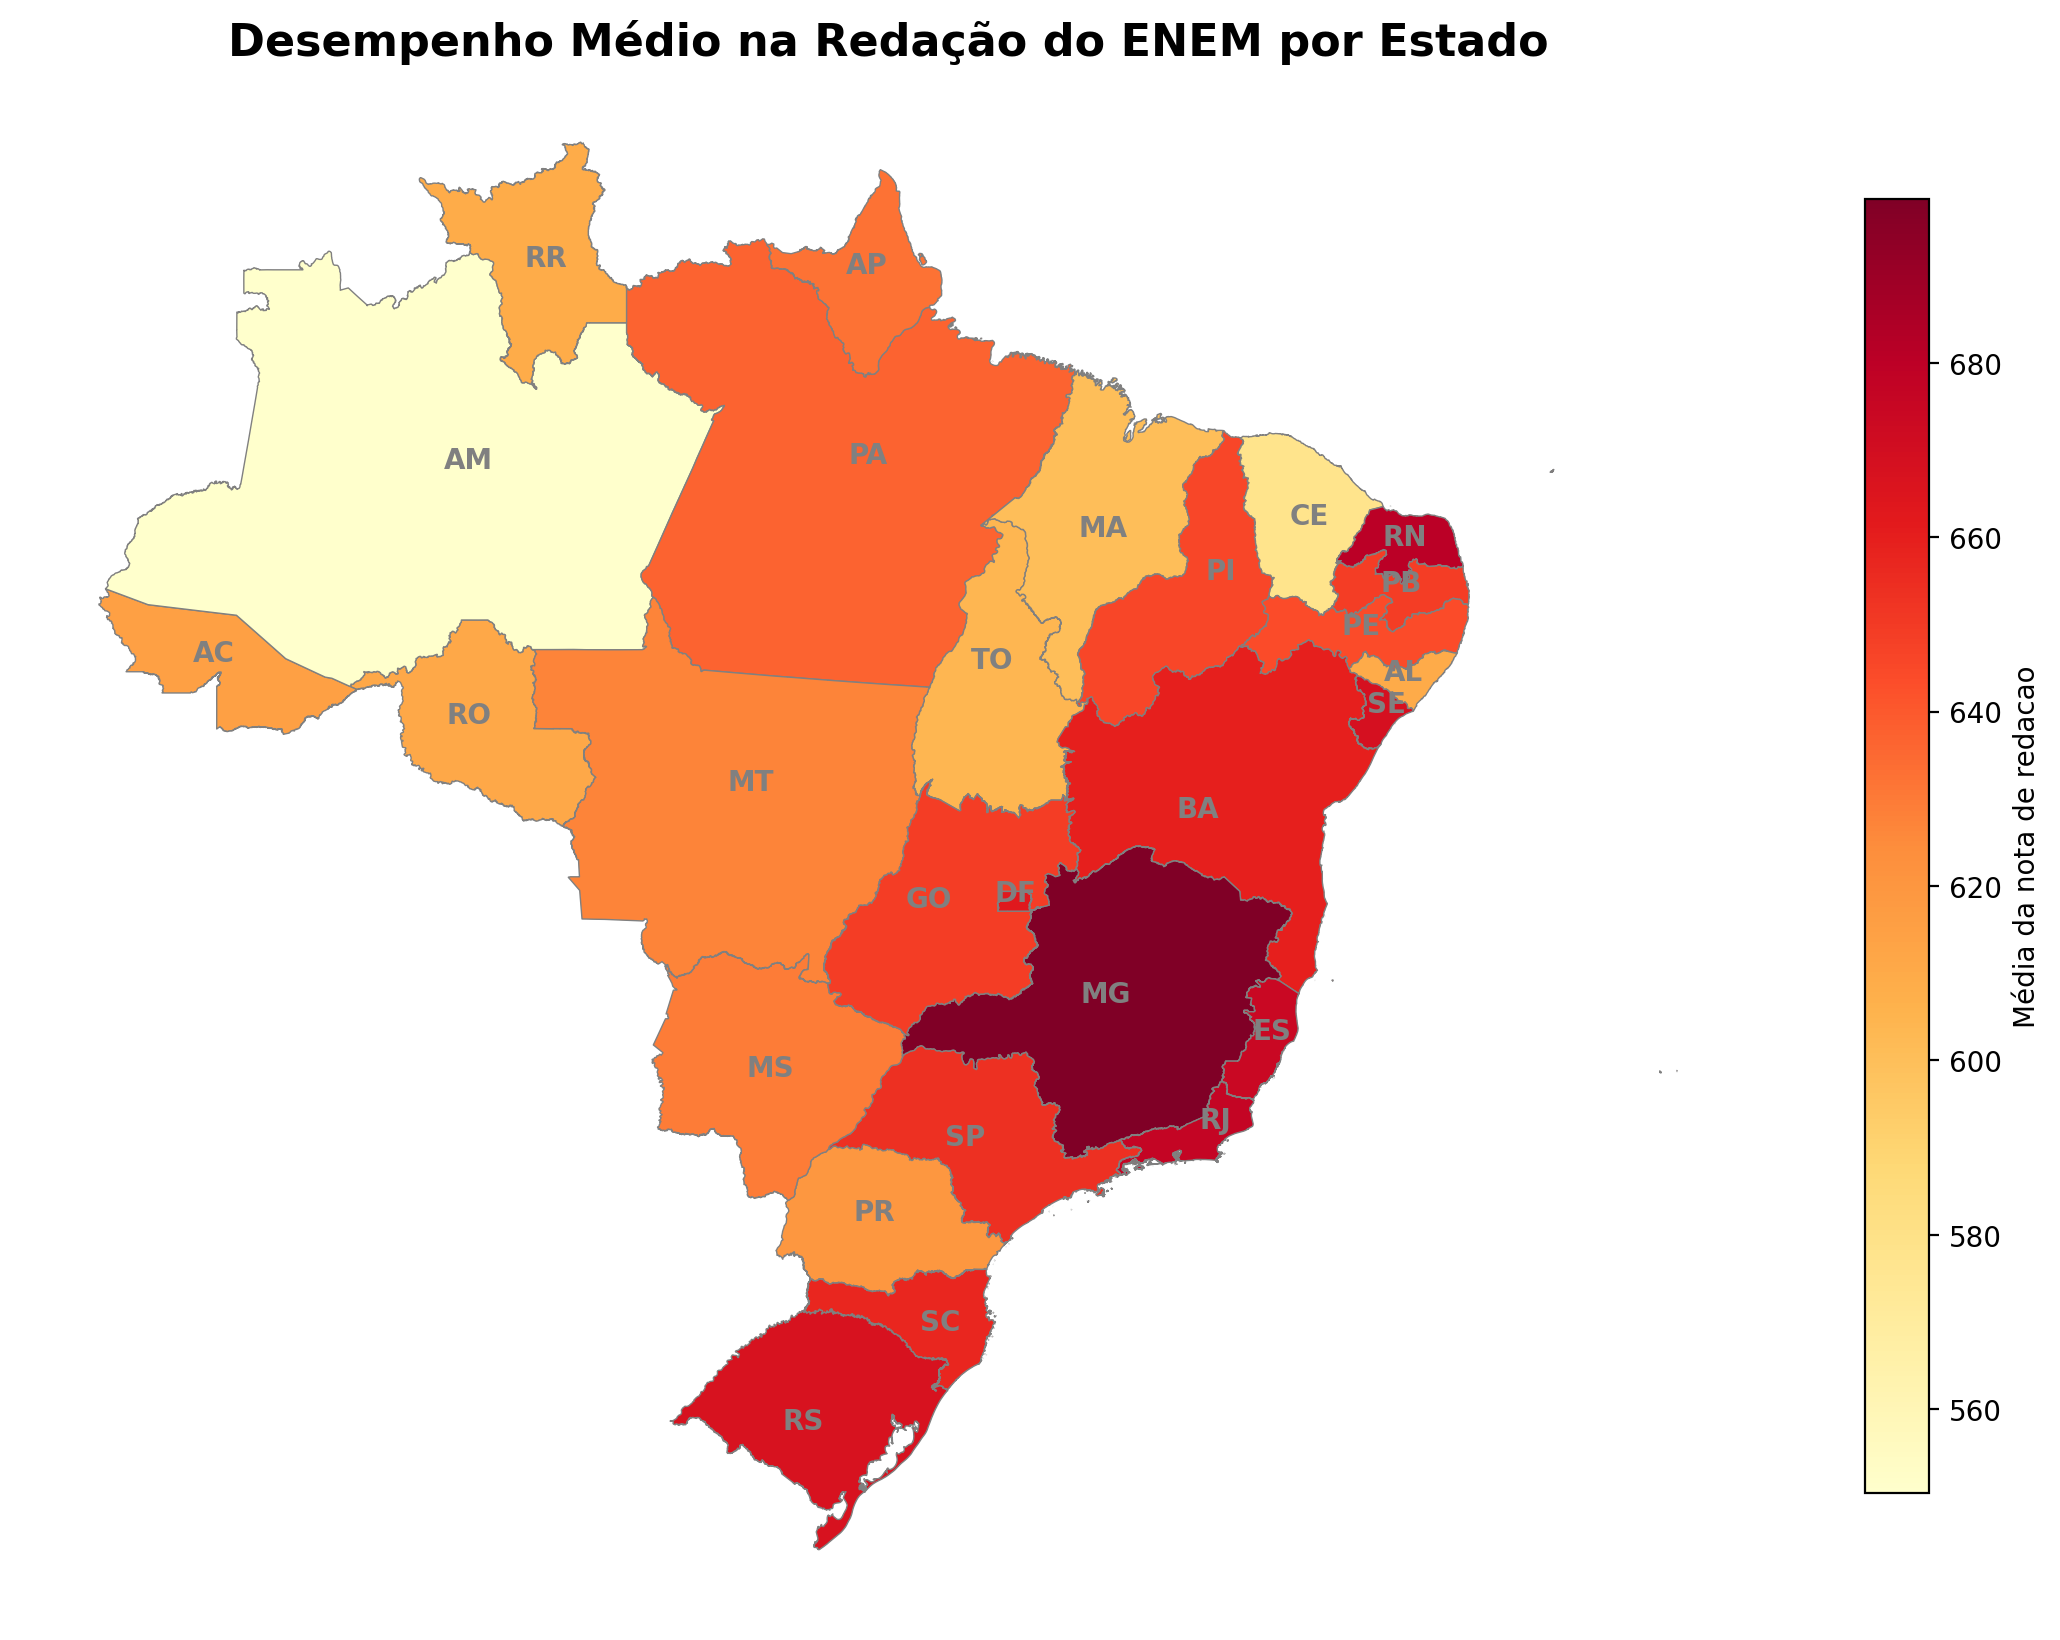

In [69]:
fig, ax = plt.subplots(figsize=(14,14),dpi=200)
mapa_por_regiao.plot(
    column = 'NU_NOTA_REDACAO',
    cmap='YlOrRd',
    linewidth=0.5,
    edgecolor='gray',
    legend = True, 
     legend_kwds={
        'label':"Média da nota de redacao",
        'orientation':"vertical",
        'shrink': 0.6
    },
    ax=ax
)
for index, linha in mapa_por_regiao.iterrows():
    ponto = linha['geometry'].representative_point()
    ax.annotate(
        text=linha['UF'],
    
    xy=(ponto.x, ponto.y),
    horizontalalignment='center',
    fontsize=10,
    fontweight='bold',
    color='gray'
    )
plt.title('Desempenho Médio na Redação do ENEM por Estado', fontsize=16, fontweight='bold')
ax.axis('off')
plt.savefig('mapa_media_enem.png', dpi=300,bbox_inches='tight')
plt.show()